'sampled_tuples_with_captions.json' 已存在，跳过创建。

--- 可视化示例 ---
正在加载 sampled_tuples_with_captions.json...
加载成功。
--- 正在可视化一个 'AAAA' 样本 (随机选择) ---


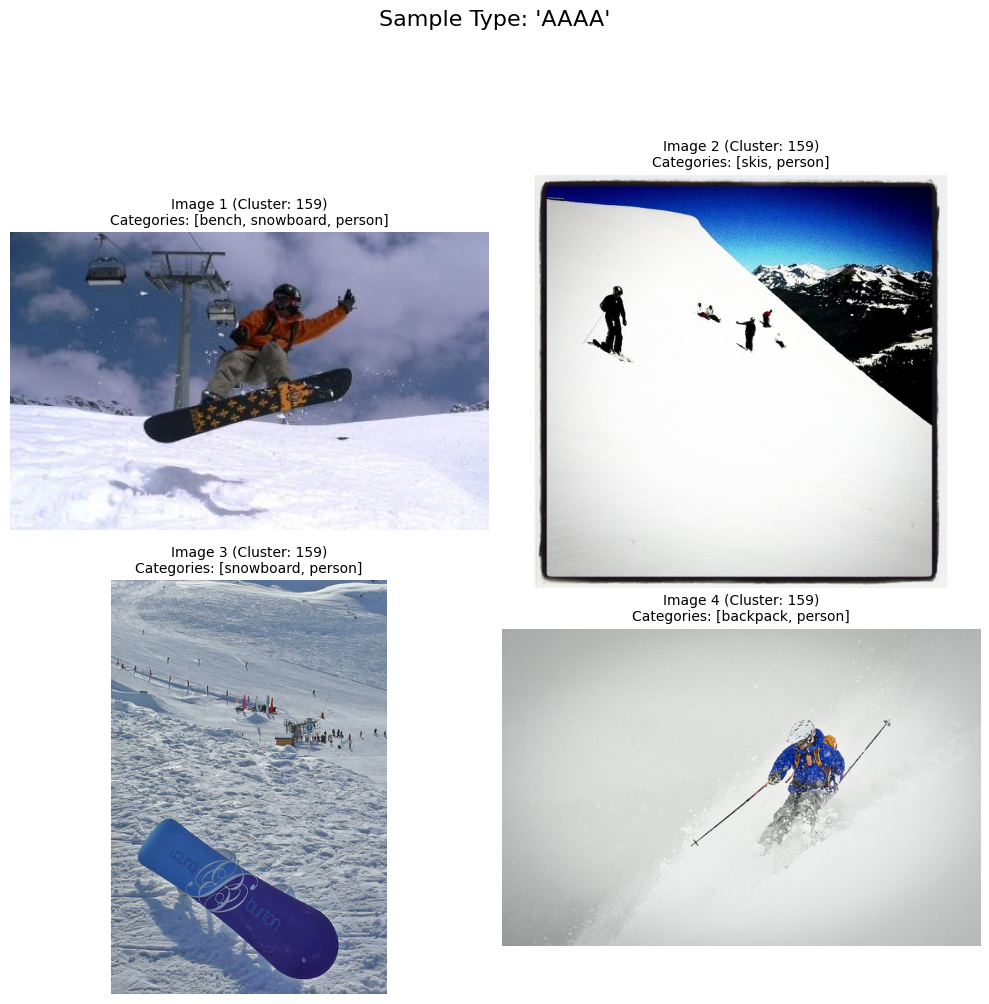

--- 正在可视化一个 'ABCD' 样本 (随机选择) ---


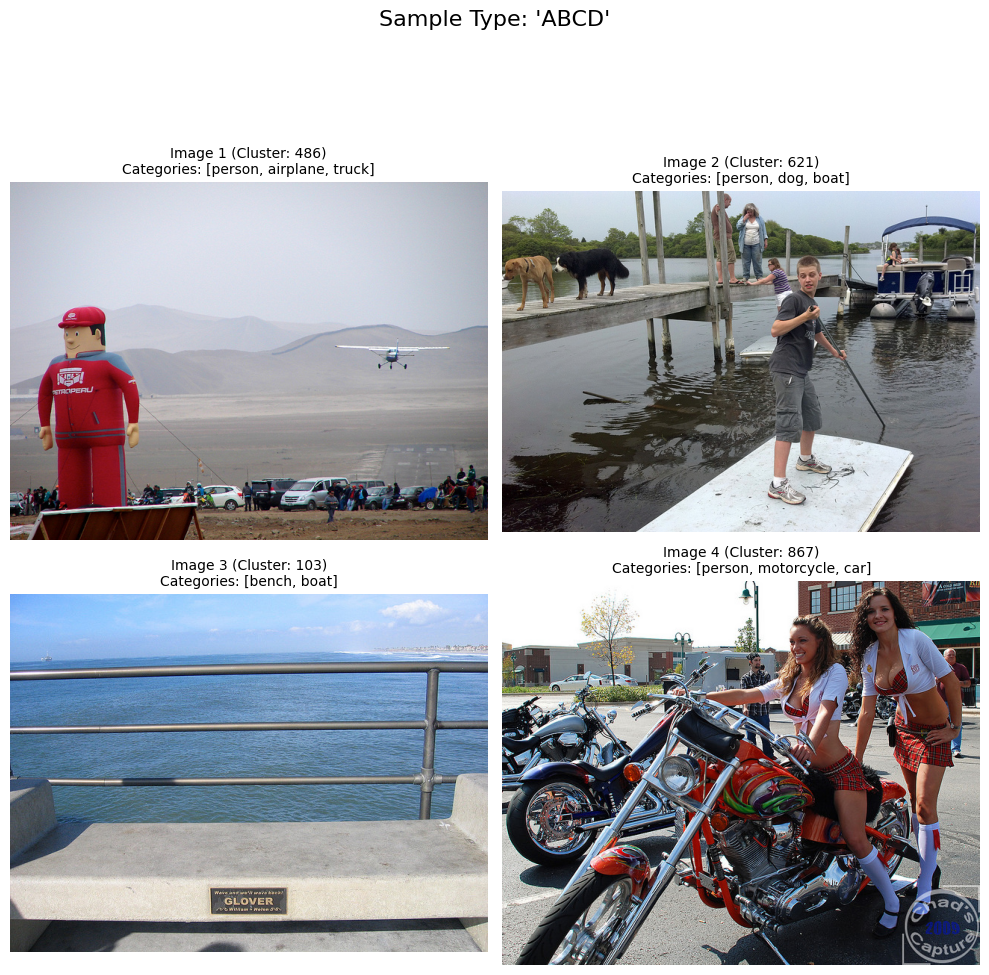

In [7]:
import json
import os
import random
import time
from collections import defaultdict
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image

# --- 1. 配置 ---
SAMPLED_FILE = '/data/home/Yitong/ZJUTruthLab/Hallucination/VLMuncertain/MultiImageBench/COCO/step1_split_images/split_images/sampled_all_tuples_k1000.json'
CAPTIONS_FILE = '/data/home/Yitong/ZJUTruthLab/Hallucination/VLMuncertain/MultiImageBench/COCO/annotations/captions_val2014.json'
INSTANCES_FILE = '/data/home/Yitong/ZJUTruthLab/Hallucination/VLMuncertain/MultiImageBench/COCO/annotations/instances_val2014.json'

# --- 输出文件 (OUT) ---
OUTPUT_ENRICHED_FILE = 'sampled_tuples_with_captions.json'

# --- 2. 目标 2: 创建“富集”的数据集 (Annotation Enrichment) ---
def create_enriched_dataset():
    """
    运行一次。加载所有源文件，创建一个包含 captions 和 categories 的新 JSON。
    """
    
    print(f"--- 开始创建富集数据集: {OUTPUT_ENRICHED_FILE} ---")
    
    # --- 步骤 1: 加载所有源文件 ---
    print("加载源文件...")
    try:
        with open(SAMPLED_FILE, 'r') as f:
            all_samples = json.load(f)
            print(f"  - 加载了 {len(all_samples)} 个样本 (来自 {SAMPLED_FILE})")
            
        with open(CAPTIONS_FILE, 'r') as f:
            captions_data = json.load(f)
            print(f"  - 加载了 captions (来自 {CAPTIONS_FILE})")

        with open(INSTANCES_FILE, 'r') as f:
            instances_data = json.load(f)
            print(f"  - 加载了 instances (来自 {INSTANCES_FILE})")

    except FileNotFoundError as e:
        print(f"错误: 找不到文件 {e.filename}。请检查上面的文件路径。")
        return
    
    # --- 步骤 2: 创建高效的查找表 (Mappings) ---
    print("正在创建标注查找表...")
    
    # 2a. 文件名 -> Image ID
    # (使用 instances_data['images'] 或 captions_data['images'] 都可以)
    file_name_to_id_map = {}
    for img_info in instances_data['images']:
        # 键是 'COCO_val2014_000000281882.jpg'
        file_name_to_id_map[img_info['file_name']] = img_info['id']
    
    # 2b. Image ID -> [Captions List]
    image_id_to_captions_map = defaultdict(list)
    for ann in captions_data['annotations']:
        image_id_to_captions_map[ann['image_id']].append(ann['caption'])
        
    # 2c. Category ID -> Category Name
    cat_id_to_name_map = {}
    for cat_info in instances_data['categories']:
        cat_id_to_name_map[cat_info['id']] = cat_info['name']
        
    # 2d. Image ID -> [Category Names List]
    # (使用 set 来自动去重)
    image_id_to_categories_map_set = defaultdict(set)
    for ann in instances_data['annotations']:
        cat_id = ann['category_id']
        cat_name = cat_id_to_name_map.get(cat_id, 'unknown')
        image_id_to_categories_map_set[ann['image_id']].add(cat_name)
    
    # 将 set 转换为 list
    image_id_to_categories_map = {
        img_id: list(cat_set) 
        for img_id, cat_set in image_id_to_categories_map_set.items()
    }
    
    print("查找表创建完毕。")

    # --- 步骤 3: 遍历并“富集”样本 ---
    print(f"正在富集 {len(all_samples)} 个样本...")
    
    enriched_samples = []
    
    for sample in tqdm(all_samples):
        new_sample = sample.copy()
        
        # 我们将用 'image_details' 替换 'image_paths'
        image_paths = new_sample.pop('image_paths', []) # 移除旧键
        new_sample['image_details'] = []
        
        for img_path in image_paths:
            # 从 '/data/home/.../COCO_val2014_...jpg' 中提取 'COCO_val2014_...jpg'
            file_name = os.path.basename(img_path)
            
            # 查找 Image ID
            image_id = file_name_to_id_map.get(file_name)
            
            if image_id:
                # 查找标注
                captions = image_id_to_captions_map.get(image_id, [])
                categories = image_id_to_categories_map.get(image_id, [])
                
                new_sample['image_details'].append({
                    "image_id": image_id,
                    "file_name": file_name,
                    "path": img_path,
                    "captions": captions,
                    "categories": categories
                })
            else:
                # 找不到 ID 的情况 (理论上不应发生)
                new_sample['image_details'].append({
                    "image_id": None,
                    "file_name": file_name,
                    "path": img_path,
                    "captions": [],
                    "categories": []
                })
                
        enriched_samples.append(new_sample)

    # --- 步骤 4: 保存新的 JSON 文件 ---
    print(f"富集完成。正在保存到 {OUTPUT_ENRICHED_FILE}...")
    with open(OUTPUT_ENRICHED_FILE, 'w') as f:
        json.dump(enriched_samples, f, indent=2)
        
    print("--- 所有工作完成！ ---")

# --- 3. 目标 1: 可视化函数 (Jupyter-ready) ---

def visualize_sample(all_enriched_samples, sample_type, sample_index=None):
    """
    从富集数据中挑选一个样本并进行可视化。
    
    参数:
    all_enriched_samples (list): 加载的 _enriched.json 文件内容
    sample_type (str): "AA", "AABB", "ABCD" 等
    sample_index (int, 可选): 挑选第 N 个样本。如果为 None，则随机挑选。
    """
    
    # 1. 过滤出该类型的所有样本
    filtered_samples = [s for s in all_enriched_samples if s['type'] == sample_type]
    
    if not filtered_samples:
        print(f"错误: 找不到类型为 '{sample_type}' 的样本。")
        return

    # 2. 挑选一个样本
    if sample_index is not None and sample_index < len(filtered_samples):
        sample_entry = filtered_samples[sample_index]
    else:
        sample_entry = random.choice(filtered_samples)
        
    print(f"--- 正在可视化一个 '{sample_type}' 样本 (随机选择) ---")
    
    # 3. 准备绘图
    image_details = sample_entry['image_details']
    cluster_ids = sample_entry['cluster_ids']
    num_images = len(image_details)
    
    # 动态设置网格
    if num_images == 4:
        rows, cols = 2, 2
    else:
        rows, cols = 1, num_images
        
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if num_images == 1: # (以防万一)
        axes = [axes]
    else:
        axes = axes.flatten()
        
    fig.suptitle(f"Sample Type: '{sample_entry['type']}'", fontsize=16, y=1.03)

    # 4. 循环绘制图片
    for i, detail in enumerate(image_details):
        ax = axes[i]
        try:
            img = Image.open(detail['path'])
            ax.imshow(img)
            
            # 准备标题
            cluster_id = cluster_ids[i]
            # (只显示前3个类别，防止标题太长)
            categories_str = ", ".join(detail['categories'][:3])
            
            ax.set_title(f"Image {i+1} (Cluster: {cluster_id})\nCategories: [{categories_str}]", fontsize=10)
            
        except FileNotFoundError:
            ax.text(0.5, 0.5, f"Image not found:\n{detail['file_name']}", 
                    ha='center', va='center', color='red')
        
        ax.axis('off')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 调整布局为总标题留出空间
    plt.show()

# --- 4. 主执行流程 (如何在 Jupyter 中使用) ---

if __name__ == "__main__":
    
    # ----------------------------------------------------
    # **步骤 1: 生成富集文件 (只需运行一次!)**
    # ----------------------------------------------------
    # 检查文件是否已存在，如果不存在，则创建它
    if not os.path.exists(OUTPUT_ENRICHED_FILE):
        print(f"'{OUTPUT_ENRICHED_FILE}' 未找到，正在创建...")
        create_enriched_dataset()
    else:
        print(f"'{OUTPUT_ENRICHED_FILE}' 已存在，跳过创建。")
        
        
    # ----------------------------------------------------
    # **步骤 2: 加载和可视化 (在 Jupyter 中反复运行)**
    # ----------------------------------------------------
    
    print("\n--- 可视化示例 ---")
    
    # 1. 加载您新生成的富集文件
    print(f"正在加载 {OUTPUT_ENRICHED_FILE}...")
    try:
        with open(OUTPUT_ENRICHED_FILE, 'r') as f:
            all_data = json.load(f)
        print("加载成功。")

        # 2. 调用可视化函数
        
        # # 示例 1: 可视化一个 'AA' (两张相似) 样本
        # visualize_sample(all_data, sample_type="AA")
        
        # # 示例 2: 可视化一个 'AB' (两张不相似) 样本
        # # visualize_sample(all_data, sample_type="AB")
        
        # 示例 3: 可视化一个 'AAAA' (四张相似) 样本
        visualize_sample(all_data, sample_type="AAAA")
        
        # # 示例 4: 可视化一个 'AABB' (两两相似) 样本
        # visualize_sample(all_data, sample_type="AABB")

        # 示例 5: 可视化一个 'ABCD' (四张不相似) 样本
        visualize_sample(all_data, sample_type="ABCD")
        
    except FileNotFoundError:
        print(f"错误: '{OUTPUT_ENRICHED_FILE}' 未找到。请先运行上面的 create_enriched_dataset()。")
    except Exception as e:
        print(f"发生错误: {e}")